## HateXplain - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech - general
* **Target 2:** Hate speech against woman

In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes #, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [7]:
task_config = {
    "General": {"type": "hate_speech"},
    "Women": {"type": "group_hate", "group": "Women"},
    #"Homosexual": {"type": "group_hate", "group": "Homosexual"},
    #"Indigenous": {"type": "group_hate", "group": "Indigenous"},
    #"African": {"type": "group_hate", "group": "African"},
    #"Asian": {"type": "group_hate", "group": "Asian"},
    #"Jewish": {"type": "group_hate", "group": "Jewish"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [02:29<00:00,  3.21it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [8]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

15:09:00 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:09:00 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:06<00:00, 36.53it/s]


Epoch 1 - Average loss: 0.7344


Epoch 2/3: 100%|██████████| 241/241 [00:08<00:00, 28.31it/s]


Epoch 2 - Average loss: 0.7173


Epoch 3/3: 100%|██████████| 241/241 [00:05<00:00, 42.31it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 84.30it/s] 


Epoch 2 - Average loss: 0.4276


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 92.61it/s] 


Epoch 3 - Average loss: 0.4292


15:41:21 | DEBUG | machinemoo | New solution dominated [0.58921117 0.34999428]
15:41:21 | DEBUG | machinemoo | Calculated weights: [0.26145478 0.73854522]
15:41:21 | DEBUG | machinemoo | Importance: 0.00010212503282663876
15:41:21 | DEBUG | machinemoo | Global lower bound (y*): [0.58883907 0.34952017]
15:41:21 | DEBUG | machinemoo | Iteration 150
15:41:21 | DEBUG | machinemoo | Solutions list: [array([0.58883907, 0.35072498]), array([0.58934583, 0.34952017]), array([0.58896134, 0.34965628]), array([0.58887354, 0.34999541]), array([0.58895814, 0.34987634]), array([0.58886688, 0.35060525])]


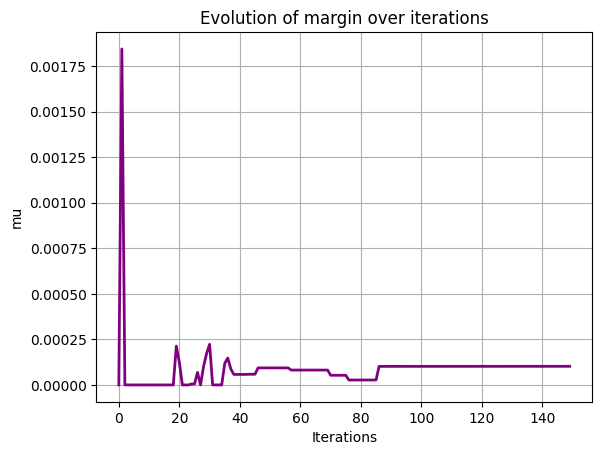

15:41:21 | INFO | machinemoo | Fit runtime: 1940.80 seconds


In [9]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [10]:
results['mola']["objectives"]

array([[0.58883907, 0.35072498],
       [0.58934583, 0.34952017],
       [0.58896134, 0.34965628],
       [0.58887354, 0.34999541],
       [0.58895814, 0.34987634],
       [0.58886688, 0.35060525]])

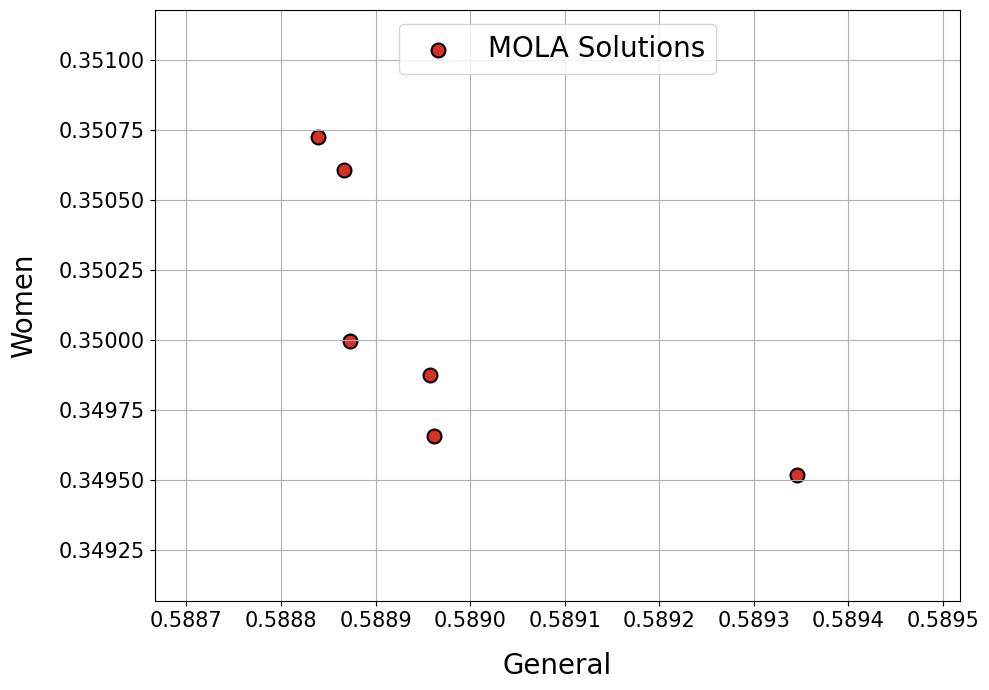

In [11]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            title=title,
            fontsize=20,
            figsize=(10,7),
            save_path='images/2_objs_mola.pdf'
            )

15:41:21 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:41:21 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 89.42it/s] 


Epoch 1 - Average loss: 0.7186


Epoch 2/3: 100%|██████████| 241/241 [00:04<00:00, 59.33it/s]


Epoch 2 - Average loss: 0.7050


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 88.66it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 100.54it/s]


Epoch 2 - Average loss: 0.6092


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 85.75it/s] 


Epoch 3 - Average loss: 0.6137


16:09:27 | DEBUG | machinemoo | New solution dominated [0.58895299 0.36583243]
16:09:27 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [0.37915774 0.25796465]
16:09:27 | DEBUG | machinemoo | Calculated weights: [1. 0.]
16:09:27 | DEBUG | machinemoo | Importance: 0.20949186693830624
16:09:27 | DEBUG | machinemoo | Global lower bound (y*): [0.37915774 0.25796465]
16:09:27 | DEBUG | machinemoo | Iteration 150
16:09:27 | DEBUG | machinemoo | Solutions list: [array([0.58864961, 0.36418845]), array([0.58873251, 0.3633326 ]), array([0.58889808, 0.36323177]), array([0.58890099, 0.3628616 ]), array([0.58937958, 0.36277526]), array([0.58932962, 0.36283056]), array([0.59146822, 0.36252906]), array([0.59209376, 0.36235267])]


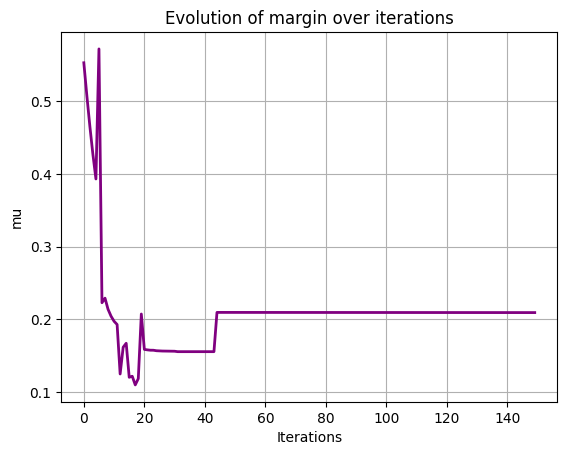

16:09:27 | INFO | machinemoo | Fit runtime: 1685.42 seconds


In [12]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

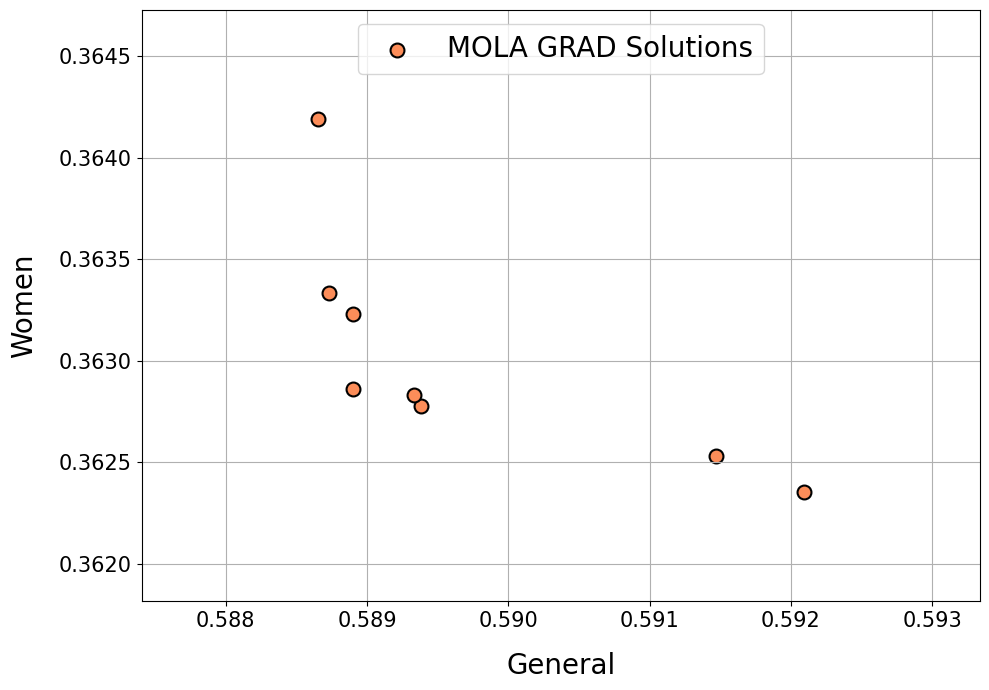

In [13]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola_grad': results["mola_grad"]["objectives"]},
            labels=task_names, 
            title=title,
            fontsize=20,
            figsize=(10,7),
            color=['#fc8d59'],
            save_path='images/2_objs_mola_grad.pdf'
            )

### Random Weight

In [14]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

16:09:27 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeGap', 'nodeTimeLimit', 'targetGap'}
16:09:27 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
16:09:27 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:03<00:00, 73.99it/s] 


Epoch 1 - Average loss: 0.7360


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 87.97it/s] 


Epoch 2 - Average loss: 0.7185


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 97.51it/s] 


...

Epoch 2/3: 100%|██████████| 241/241 [00:03<00:00, 76.49it/s]


Epoch 2 - Average loss: 0.4875


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 82.97it/s] 


Epoch 3 - Average loss: 0.4885


16:38:02 | DEBUG | machinemoo | 150th solution


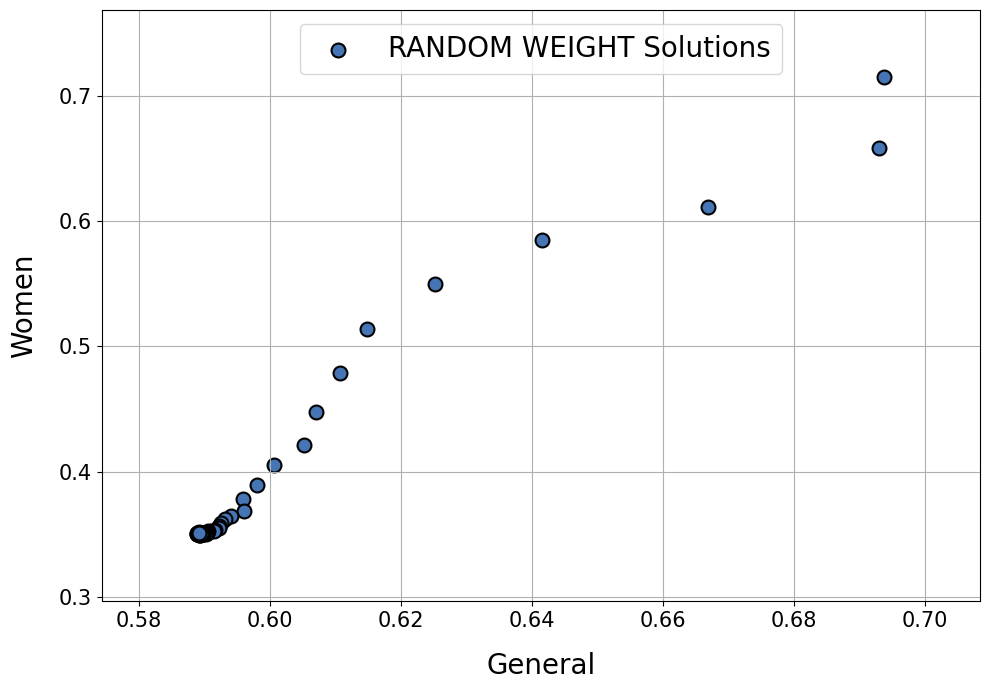

In [15]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'random_weight': results["random_weight"]["objectives"]},
            labels=task_names, 
            title=title,
            fontsize=20,
            figsize=(10,7),
            color=['#4575b4'],
            save_path='images/2_objs_rw.pdf'
            )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

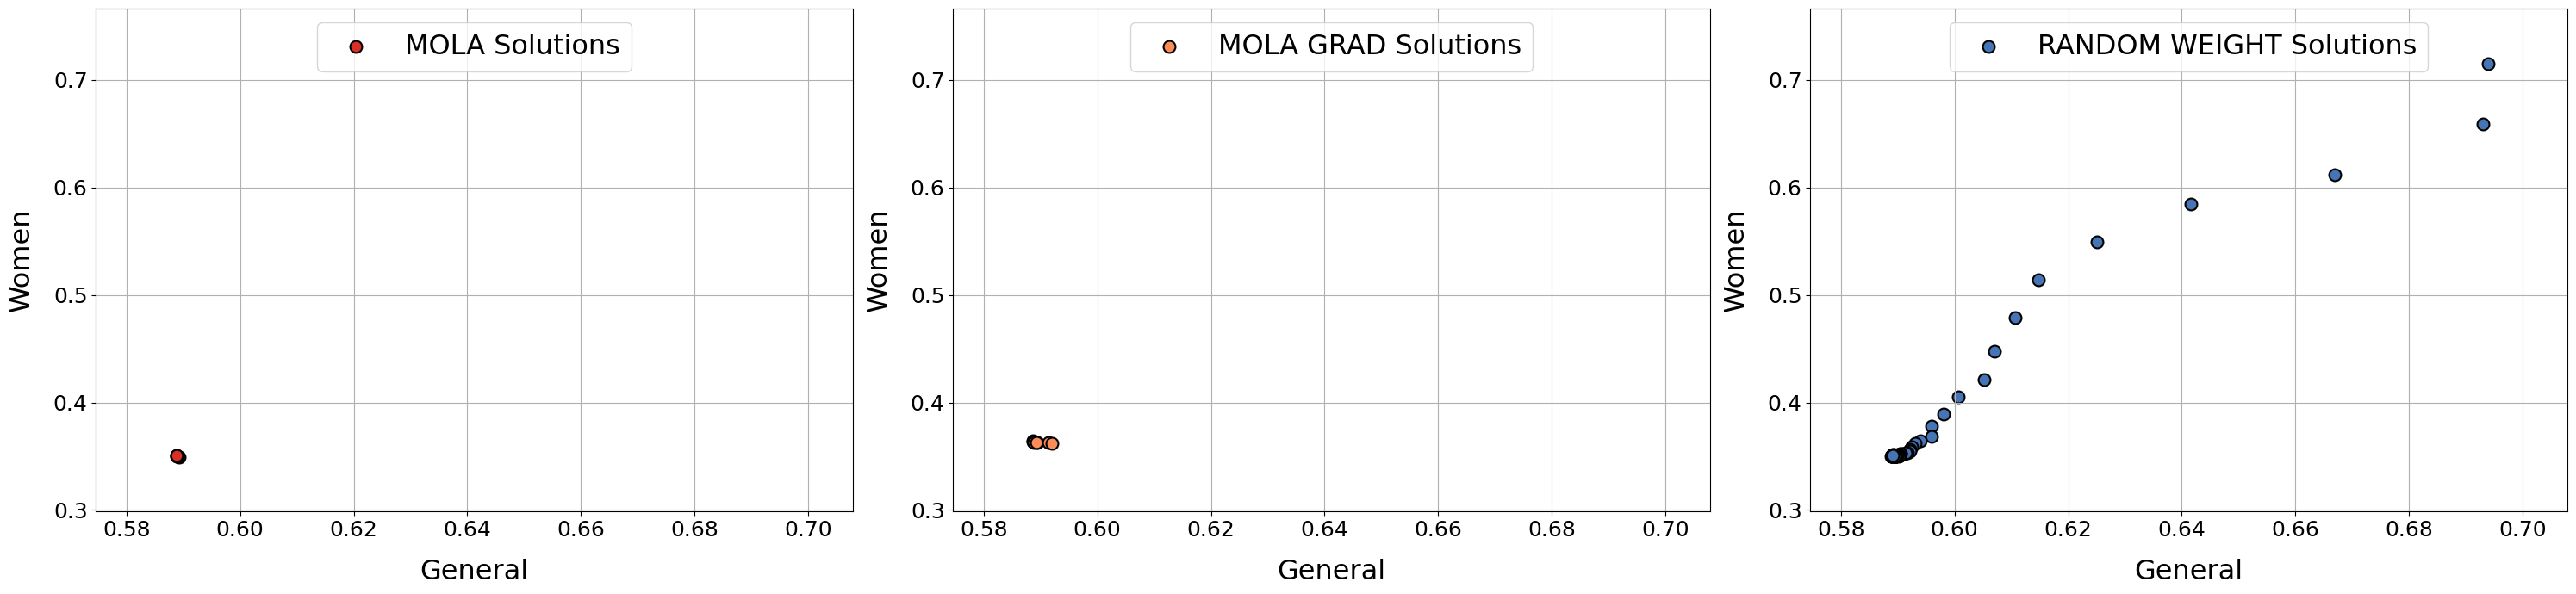

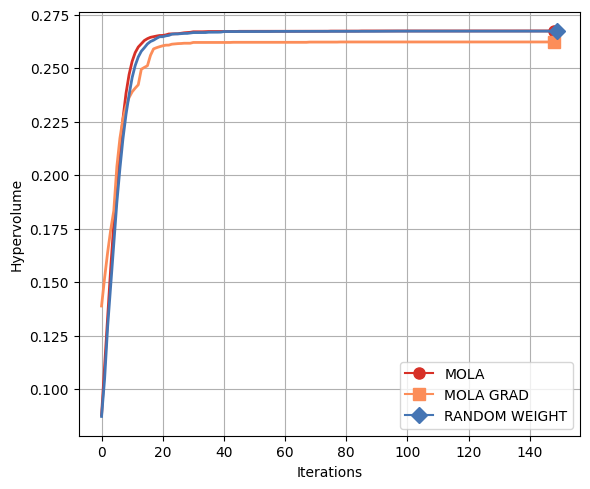

<Figure size 640x480 with 0 Axes>

In [16]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/2_objs_hypervolume.pdf")

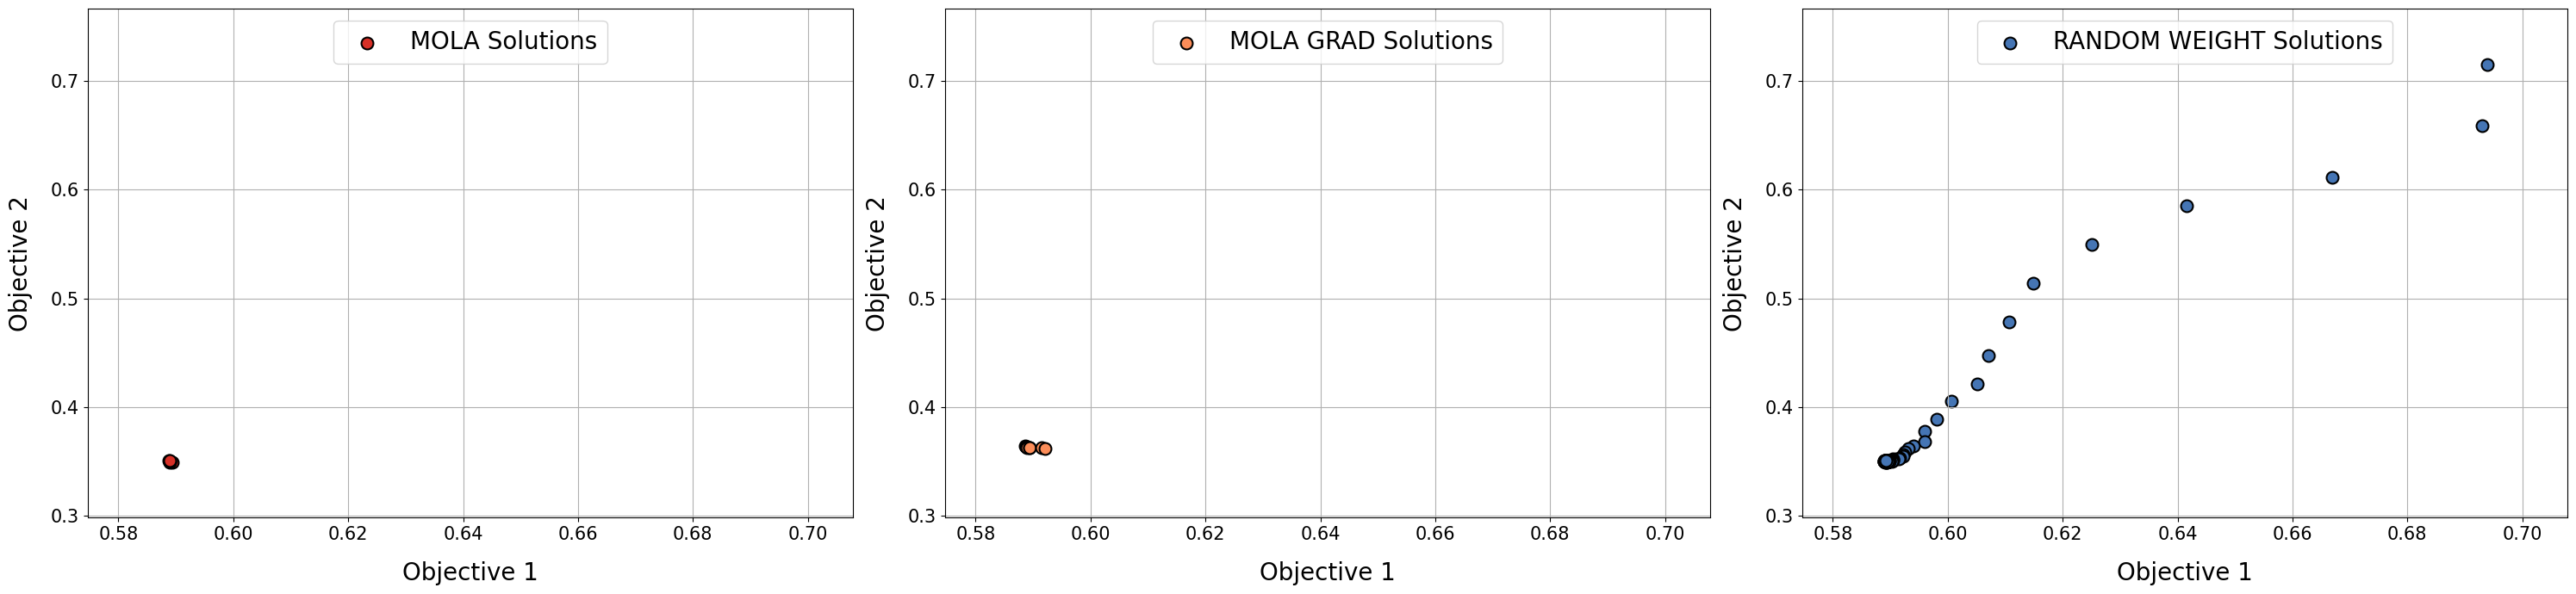

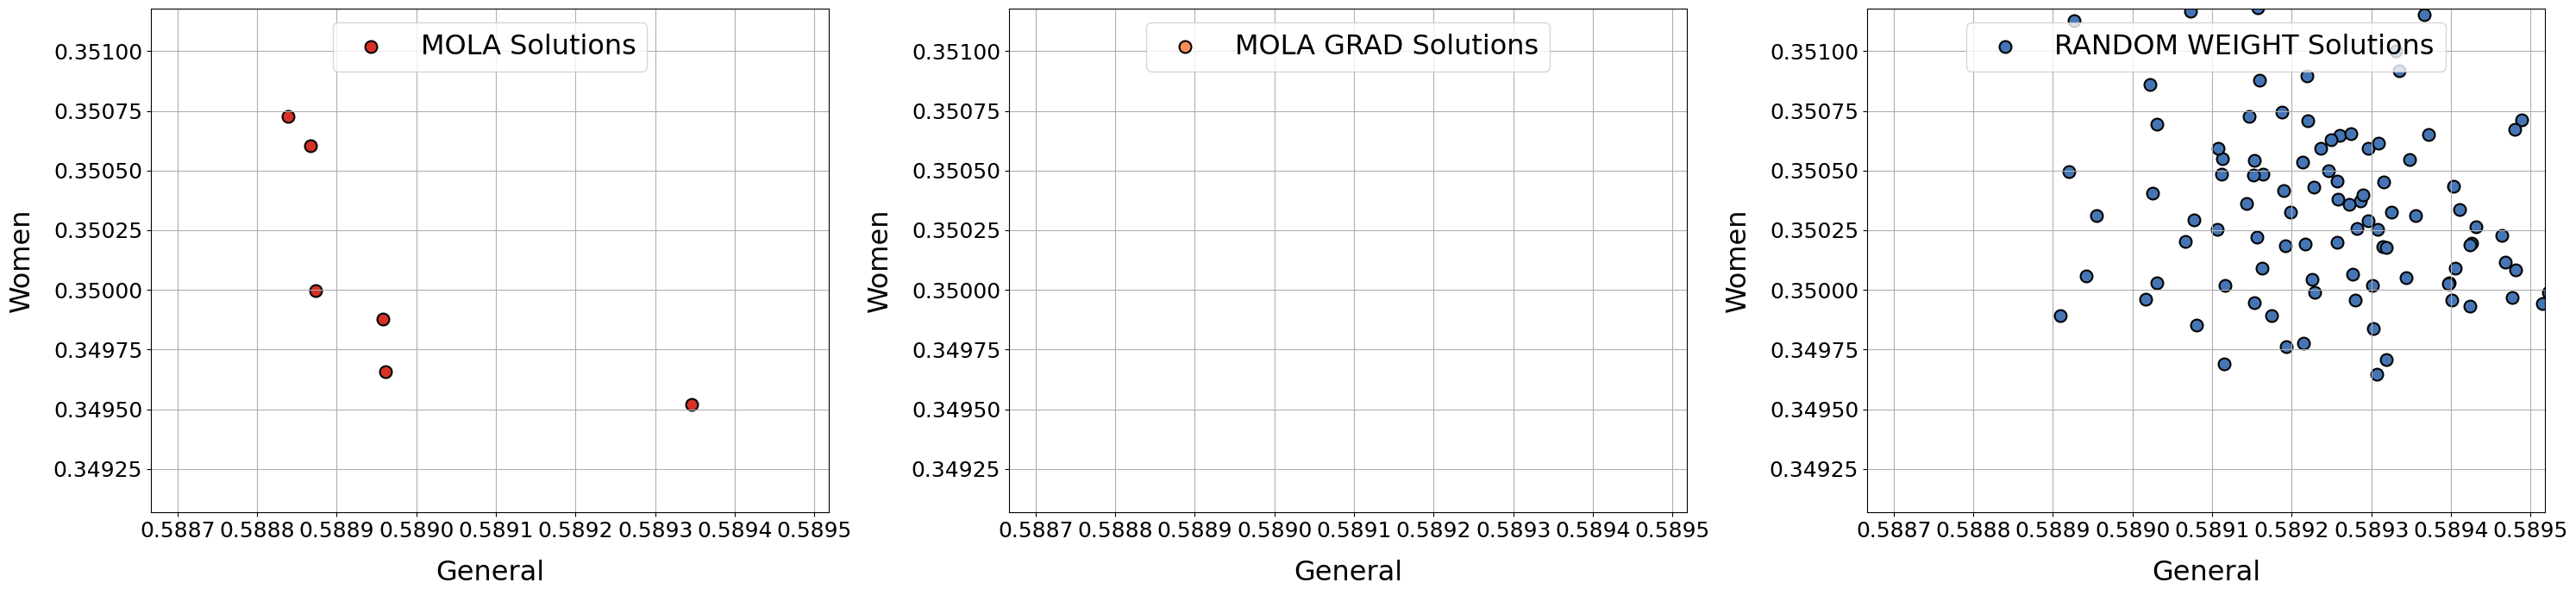

In [17]:
from machinemoo.analysis.visualization import plot_pareto_set_limit
plot_pareto_set_limit(methods=pareto_dict, axis_mode="global")
plot_pareto_set_limit(methods=pareto_dict, 
                      axis_mode="first", 
                      title="",
                      labels=task_names, 
                      fontsize=23,
                      figsize=(10,7),
                      save_path="images/2_objs_limit.pdf")

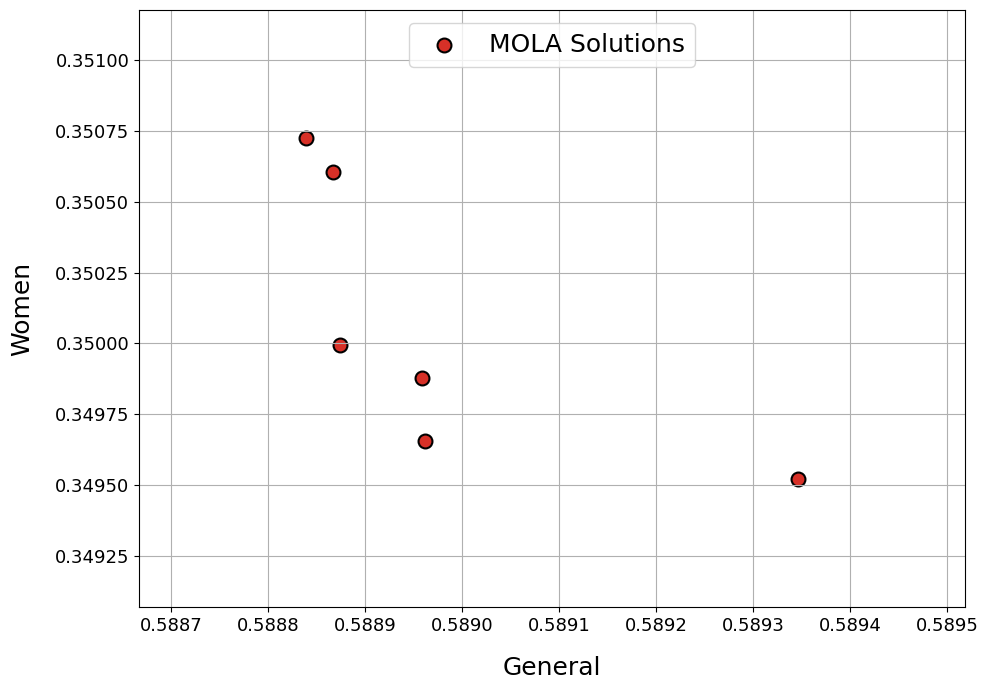

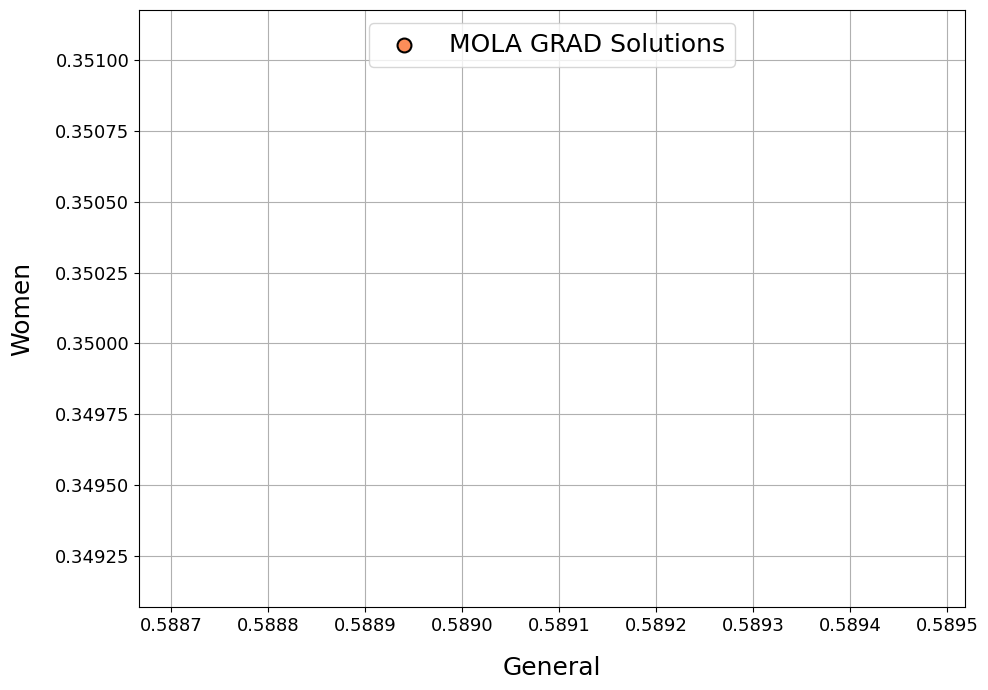

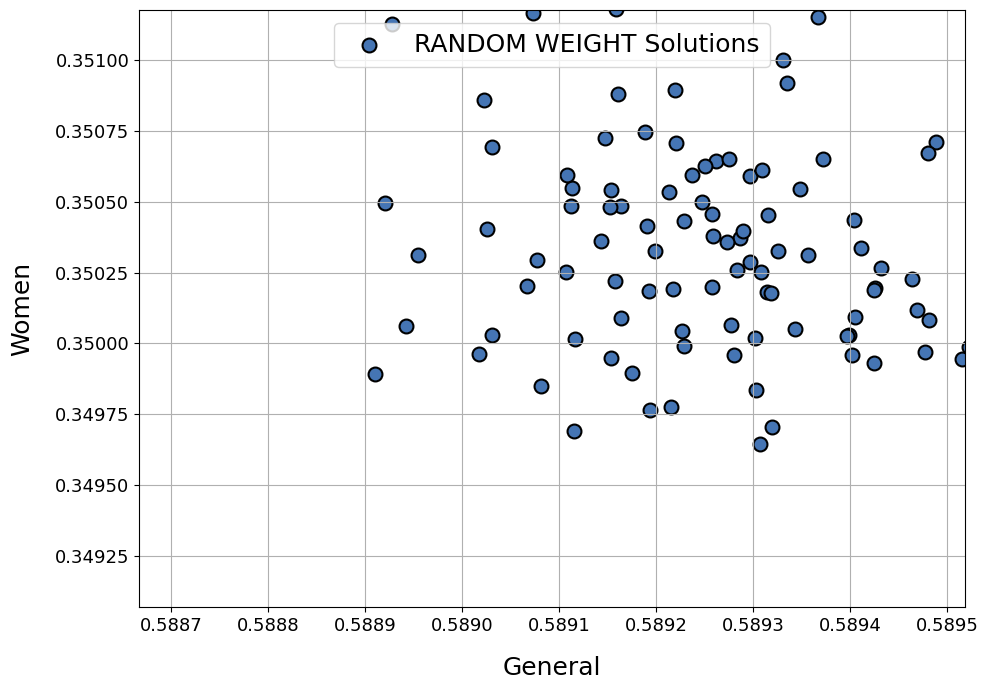

In [18]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

#for i in range(all_data.shape[1]):
#    limits.append(
#        (
#            all_data[:, i].min() - all_data[:, i].std(),
#            all_data[:, i].max() + all_data[:, i].std(),
#        )
#    )
first_objs = next(iter(pareto_dict.values()))
x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()

limits.append((x_min, x_max))
limits.append((y_min, y_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=task_names, 
                title=title,
                fontsize=18,
                figsize=(10,7),
                save_path=f'images/2_objs_{method}_limit.pdf',
                limits=limits
    )

In [19]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

mola: 6
mola_grad: 8
Número de soluções não-dominadas (RW): 4
[[0.58908076 0.34985113]
 [0.58930674 0.34964545]
 [0.58911508 0.34969168]
 [0.58890959 0.34989267]]


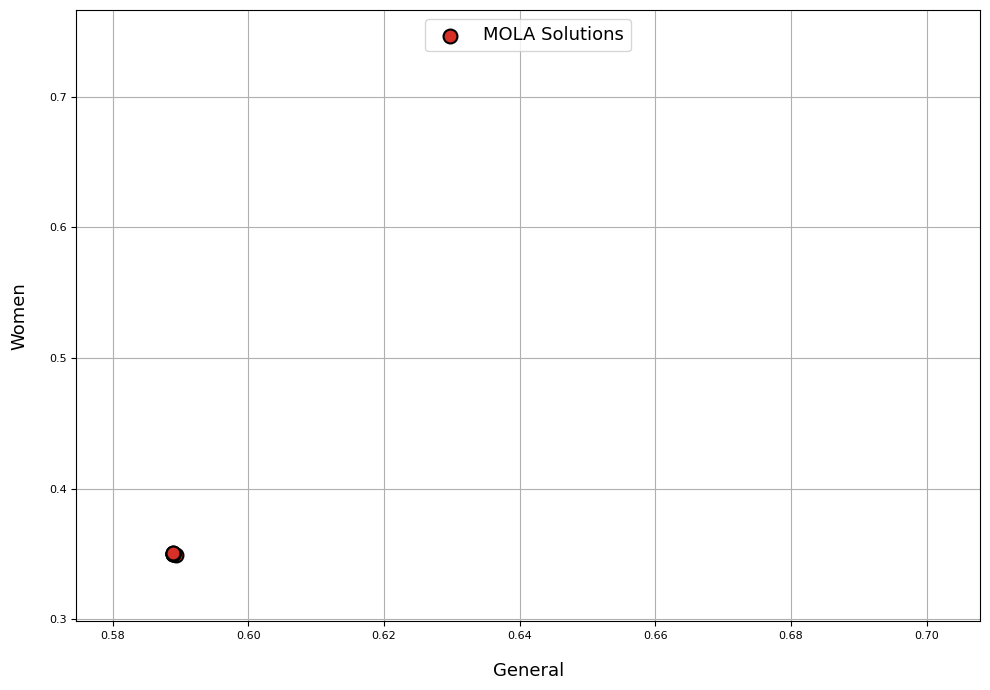

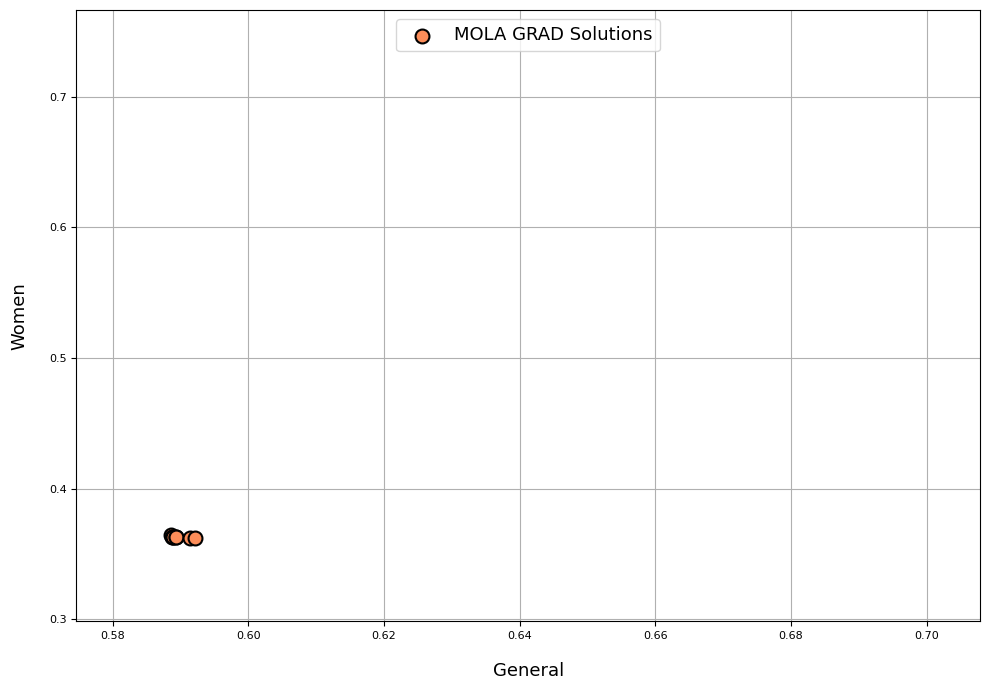

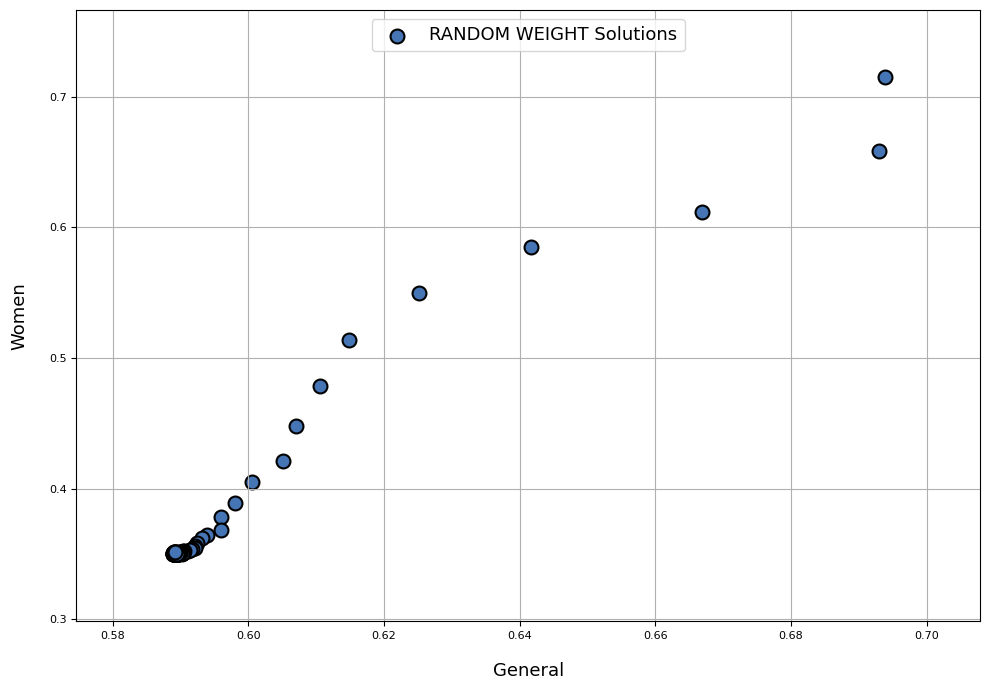

In [22]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

for i in range(all_data.shape[1]):
    limits.append(
        (
            all_data[:, i].min() - all_data[:, i].std(),
            all_data[:, i].max() + all_data[:, i].std(),
        )
    )
#first_objs = next(iter(pareto_dict.values()))
#x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
#y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()
#z_min, z_max = first_objs[:, 2].min() - first_objs[:, 2].std(), first_objs[:, 2].max() + first_objs[:, 2].std()

#limits.append((x_min, x_max))
#limits.append((y_min, y_max))
#limits.append((z_min, z_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=task_names, 
                title=title,
                fontsize=13,
                figsize=(10,7),
                save_path=f'images/3_objs_{method}_limit.pdf',
                limits=limits
    )